In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import matplotlib.pyplot as plt
import seaborn as sn
import emoji

In [2]:
df = pd.read_csv('../data/features/youtube_features.csv')


In [3]:
def get_plain_text(text):
    text = str(text)
    text = re.sub(r'http\S+|wwww\S+', '', text)
    text = ''.join(ch for ch in text if ch.isalnum() or ch.isspace() or ch in emoji.EMOJI_DATA)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [4]:
df['title_cleaned'] = df['title'].apply(get_plain_text)

In [5]:
tfidf = TfidfVectorizer(max_features=50,
                        stop_words='english',
                        ngram_range=(1, 2), 
                        min_df = 2,
                        max_df = .8
                        )

In [6]:
tfidf_matrix = tfidf.fit_transform(df['title_cleaned'])

In [7]:
feature_names = tfidf.get_feature_names_out()
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"\nTop 50 features extracted:")
print(feature_names)

TF-IDF matrix shape: (55886, 50)

Top 50 features extracted:
['10' '2017' '2018' 'au' 'avec' 'best' 'dans' 'des' 'du' 'dã' 'en' 'ep'
 'episode' 'est' 'et' 'france' 'ft' 'game' 'hd' 'highlights' 'je' 'johnny'
 'la' 'le' 'les' 'live' 'music' 'new' 'official' 'pas' 'plus' 'pour' 'qui'
 'rã' 'season' 'son' 'sur' 'trailer' 'trump' 'tv' 'une' 'video' 'vs' 'ðÿ'
 'øø' 'øùøùùø' 'ùø³ùø³ù' 'ùù' 'ùùš' 'ùˆ']


In [8]:
def is_title_english(text, top_words):
    """
    Returns True if majority of top_words are present in the title, else False
    """
    words = set(str(text).split())
    num_top_words = len(words & set(top_words))
    return num_top_words >= len(top_words) / 2  # majority rule


In [9]:
df['is_title_english'] = df['title_cleaned'].apply(lambda x: is_title_english(x, feature_names))
df['top50_score'] = df['title_cleaned'].apply(lambda x: len(set(x.split()) & set(feature_names)) / len(feature_names))

In [10]:
tfidf_matrix = tfidf.fit_transform(df['title_cleaned'])
feature_names = tfidf.get_feature_names_out()

print(f"Filtered dataset shape: {df.shape}")
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"\nTop 50 features extracted:\n{feature_names}")

Filtered dataset shape: (55886, 27)
TF-IDF matrix shape: (55886, 50)

Top 50 features extracted:
['10' '2017' '2018' 'au' 'avec' 'best' 'dans' 'des' 'du' 'dã' 'en' 'ep'
 'episode' 'est' 'et' 'france' 'ft' 'game' 'hd' 'highlights' 'je' 'johnny'
 'la' 'le' 'les' 'live' 'music' 'new' 'official' 'pas' 'plus' 'pour' 'qui'
 'rã' 'season' 'son' 'sur' 'trailer' 'trump' 'tv' 'une' 'video' 'vs' 'ðÿ'
 'øø' 'øùøùùø' 'ùø³ùø³ù' 'ùù' 'ùùš' 'ùˆ']


In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
tfidf_dense = tfidf_matrix.toarray()
top50_pca = pca.fit_transform(tfidf_dense[:, :50])

df["top50_pca1"] = top50_pca[:, 0]
df["top50_pca2"] = top50_pca[:, 1]
df["top50_pca3"] = top50_pca[:, 2]


Top 20 most important words:
        word  avg_tfidf
2       2018   0.062750
22        la   0.044018
12   episode   0.041795
23        le   0.039045
24       les   0.033188
42        vs   0.028316
8         du   0.028092
14        et   0.026249
10        en   0.021814
1       2017   0.021591
7        des   0.017811
0         10   0.017155
41     video   0.016347
28  official   0.016125
38     trump   0.015188
27       new   0.014219
45    øùøùùø   0.013497
4       avec   0.013436
16        ft   0.013026
9         dã   0.012835


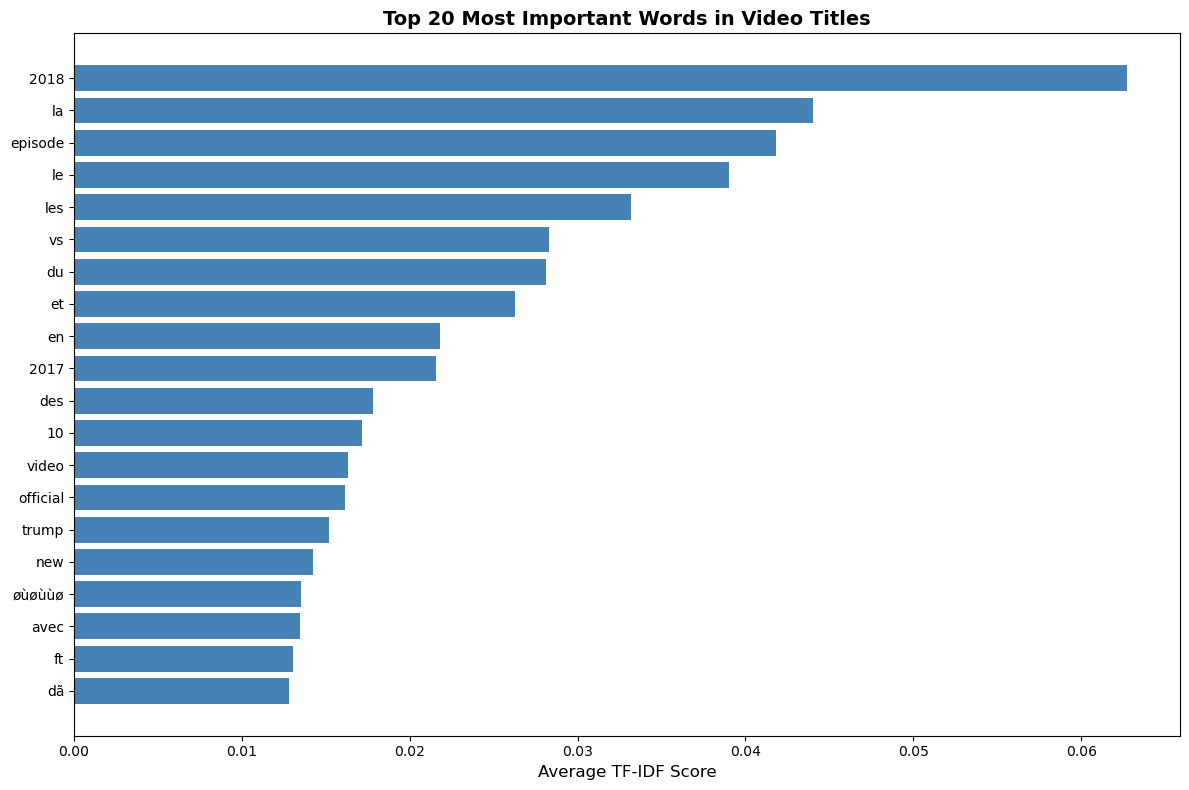

In [12]:
word_importance = tfidf_matrix.mean(axis=0).A1
word_importance_df = pd.DataFrame({
    'word': feature_names,
    'avg_tfidf': word_importance
}).sort_values('avg_tfidf', ascending=False)

print("Top 20 most important words:")
print(word_importance_df.head(20))


plt.figure(figsize=(12, 8))
top_20 = word_importance_df.head(20)
plt.barh(range(len(top_20)), top_20['avg_tfidf'], color='steelblue')
plt.yticks(range(len(top_20)), top_20['word'])
plt.xlabel('Average TF-IDF Score', fontsize=12)
plt.title('Top 20 Most Important Words in Video Titles', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/processed/tfidf_top_words.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
from collections import Counter
def extract_emojis(text):
    return [ch for ch in text if ch in emoji.EMOJI_DATA]

# Flatten all emojis into one list
all_emojis = [em for text in df['title_cleaned'] for em in extract_emojis(text)]

# Count top emojis
emoji_counts = Counter(all_emojis).most_common(20)

print("🎉 Top Emojis Used:")
for e, count in emoji_counts:
    print(f"{e}  →  {count} times")


🎉 Top Emojis Used:
©  →  18188 times
®  →  5216 times
™  →  3072 times


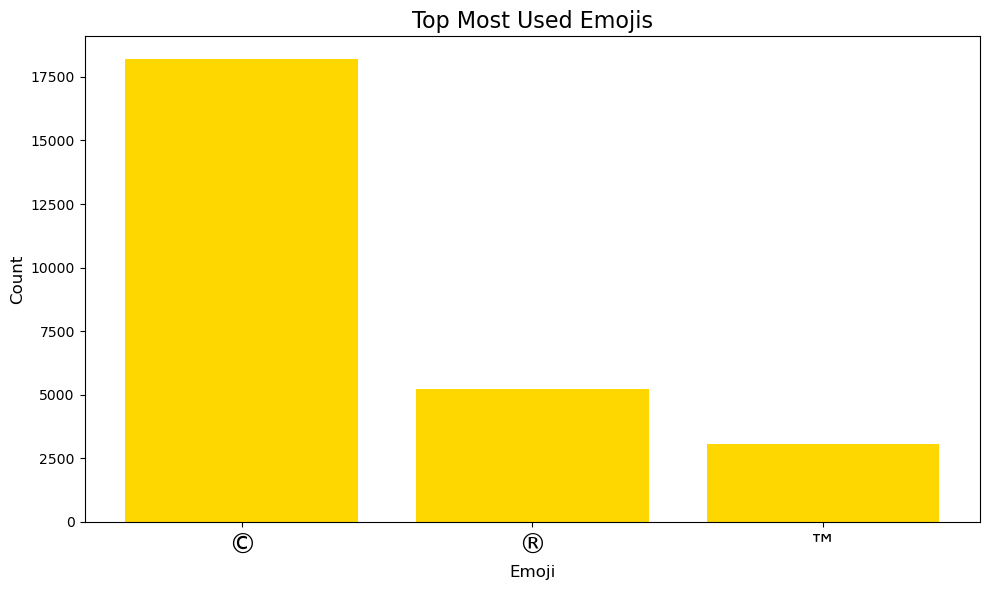

In [14]:
if emoji_counts:
    emojis, counts = zip(*emoji_counts)

    plt.figure(figsize=(10, 6))
    bars = plt.bar(emojis, counts, color='gold')

    plt.title("Top Most Used Emojis", fontsize=16)
    plt.xlabel("Emoji", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("No emojis found in dataset.")